# 08. 주피터에서 OpenCV — `cv2.imshow` 를 쓰면 안 되는 이유

이 저장소의 옛 노트북 10개 중 9개가 이렇게 끝난다.

```python
cv2.imshow('img', img)
cv2.waitKey()
cv2.destroyAllWindows()
```

노트북에서 이 세 줄은 **커널을 멈춘 것처럼 보이게** 만든다. 그래서 그 노트북들에는
결과 이미지가 하나도 남아 있지 않다 — 나중에 열어 보면 무엇을 했는지 알 수 없다.

## 학습 목표
1. `cv2.imshow` 가 노트북에서 문제인 이유와 대안
2. BGR↔RGB — matplotlib 로 그릴 때 색이 뒤집히는 문제
3. 여러 단계를 한눈에 비교하는 표시 패턴
4. 옛 노트북들이 공통으로 밟은 함정 4가지
5. 본격적인 OpenCV 학습은 어디서 이어갈지

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nbtools").is_dir())
sys.path.insert(0, str(ROOT))
from nbtools import use_korean_font  # noqa: E402
from nbtools.display import imshow, sample_image  # noqa: E402

use_korean_font()      # 그래프 제목에 한글을 쓰려면 필요하다 (05 노트북 §1)
print("OpenCV", cv2.__version__)
img = sample_image()          # 외부 파일 없이 코드로 만든 실습 이미지
print("shape", img.shape, "dtype", img.dtype)

OpenCV 5.0.0
shape (320, 480, 3) dtype uint8


## 1. `cv2.imshow` 대신 matplotlib

`cv2.imshow` 는 **OS 의 GUI 창**을 띄우고, `cv2.waitKey` 가 그 창의 이벤트 루프를 돌린다.
주피터 커널은 별도 프로세스라 그 창을 관리할 주체가 없다. 결과는 셋 중 하나다.

* 창이 뜨지 않고 셀이 `[*]` 상태로 멈춘다
* 응답 없는 회색 창이 뜬다
* (headless 환경) `cv2.error: The function is not implemented`

노트북에서는 **matplotlib 으로 인라인 출력**이 정답이다. 단, 채널 순서를 바꿔야 한다.

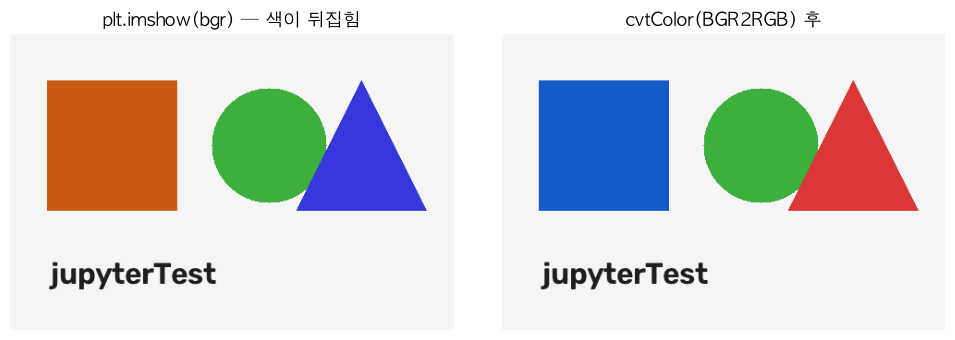

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].imshow(img)                                        # 틀린 예: BGR 배열을 그대로
axes[0].set_title("plt.imshow(bgr) — 색이 뒤집힘")
axes[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))       # 정답
axes[1].set_title("cvtColor(BGR2RGB) 후")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

파란 사각형이 빨갛게, 빨간 삼각형이 파랗게 보인다. OpenCV 는 **BGR**, matplotlib·PIL 은 **RGB** 순서다.
매번 쓰기 번거로우니 이 저장소는 `nbtools.display.imshow()` 로 감싸 두었다.

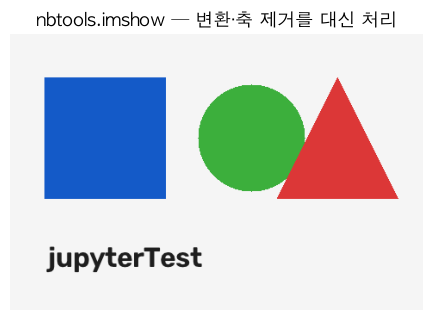

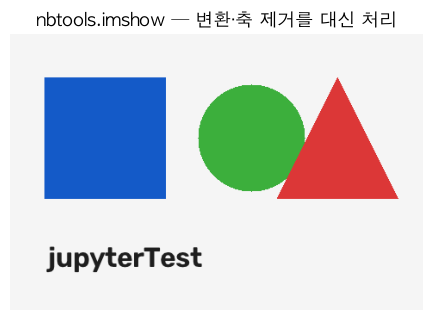

In [3]:
imshow(img, "nbtools.imshow — 변환·축 제거를 대신 처리")

## 2. 단계별 결과를 한눈에

이미지 처리는 "이 단계에서 무엇이 달라졌는가"를 봐야 한다. 셀마다 한 장씩 띄우면 비교가 안 되니
격자로 한 번에 그린다.

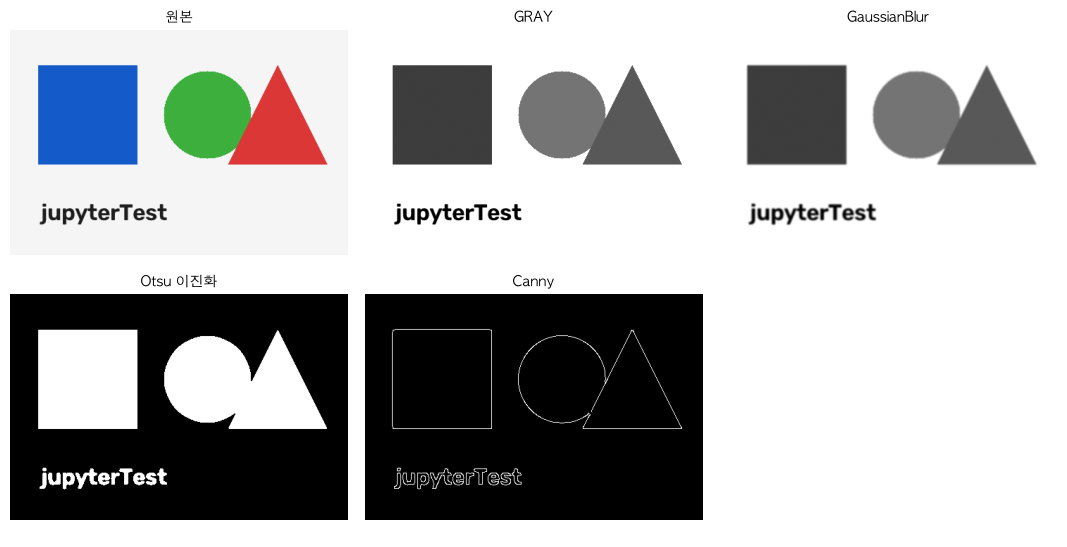

In [4]:
def show_steps(steps: dict[str, np.ndarray], cols: int = 3, size: float = 3.6) -> None:
    """{제목: 이미지} 를 격자로 그린다. 흑백/컬러를 자동 판별한다."""
    rows = (len(steps) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows * 0.78))
    for ax, (title, image) in zip(np.ravel(axes), steps.items()):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    for ax in np.ravel(axes)[len(steps):]:
        ax.axis("off")
    fig.tight_layout()


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
edges = cv2.Canny(blur, 50, 150)

show_steps({"원본": img, "GRAY": gray, "GaussianBlur": blur, "Otsu 이진화": binary, "Canny": edges})

## 3. 옛 노트북들이 공통으로 밟은 함정

### ① `findContours` 의 반환값 개수

OpenCV 3 은 3개(`image, contours, hierarchy`), **4 부터는 2개**다.
`legacy/` 의 노트북들은 2개로 받고 있어 이 부분은 지금도 맞다.

In [5]:
result = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"findContours 반환값 {len(result)}개 — OpenCV {cv2.__version__}")
contours, hierarchy = result
print(f"컨투어 {len(contours)}개")

findContours 반환값 2개 — OpenCV 5.0.0
컨투어 13개


### ② `np.array(contours)` — 지금은 예외

`legacy/cv2 test.ipynb` 의 코드다. 컨투어마다 점 개수가 달라 NumPy 1.24 부터 실패한다 (02 노트북 §8).

In [6]:
try:
    np.array(contours)
except ValueError as exc:
    print("ValueError:", str(exc)[:100], "...")

print("\n해결 — 좌표를 합칠 목적이라면 vstack:")
x, y, w, h = cv2.boundingRect(np.vstack(contours))
print(f"전체 바운딩 박스 = ({x}, {y}, {w}, {h})")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dim ...

해결 — 좌표를 합칠 목적이라면 vstack:
전체 바운딩 박스 = (40, 50, 410, 227)


### ③ 이중 for 문으로 min/max 찾기

옛 코드는 전체 좌표의 최소·최대를 이렇게 구했다.

```python
for i in range(len(contours_xy)):
    for j in range(len(contours_xy[i])):
        value.append(contours_xy[i][j][0][0])
        x_min = min(value)      # 반복마다 리스트 전체를 다시 훑는다 → O(n²)
        x_max = max(value)
```

같은 결과를 한 줄로, 그리고 훨씬 빠르게 얻을 수 있다.

In [7]:
points = np.vstack(contours).reshape(-1, 2)
print("x 범위:", points[:, 0].min(), "~", points[:, 0].max())
print("y 범위:", points[:, 1].min(), "~", points[:, 1].max())
print("(cv2.boundingRect 를 쓰면 이마저도 필요 없다)")

x 범위: 40 ~ 449
y 범위: 50 ~ 276
(cv2.boundingRect 를 쓰면 이마저도 필요 없다)


### ④ 하드코딩된 개인 PC 경로

```python
imgPath = "C:/Users/gridone/Desktop/imagesdata/test_2.png"
img = cv2.imread('Xc7y3Q_2019111_132047_38_CV2.png', cv2.IMREAD_COLOR)   # 저장소에 없는 파일
```

`cv2.imread` 는 실패해도 예외를 내지 않고 **`None`** 을 준다. 그래서 에러는 세 줄 뒤
`cv2.imshow` 에서 `size.width>0 && size.height>0` 라는 엉뚱한 메시지로 터진다.
읽자마자 검사하는 습관 하나로 디버깅 시간이 크게 줄어든다.

In [8]:
missing = cv2.imread("존재하지_않는_파일.png")
print("존재하지 않는 파일의 imread 결과:", missing)

def imread_or_die(path: str | Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {path}")
    return image

try:
    imread_or_die("존재하지_않는_파일.png")
except FileNotFoundError as exc:
    print("의도한 예외:", exc)

존재하지 않는 파일의 imread 결과: None
의도한 예외: 이미지를 읽을 수 없습니다: 존재하지_않는_파일.png


[ WARN:0@5.073] global loadsave.cpp:278 findDecoder imread_('존재하지_않는_파일.png'): can't open/read file: check file path/integrity
[ WARN:0@5.074] global loadsave.cpp:278 findDecoder imread_('존재하지_않는_파일.png'): can't open/read file: check file path/integrity


## 4. 결과를 파일로도 남기기

노트북 출력은 커널을 재시작하면 사라진다. 중요한 산출물은 파일로 저장한다.

저장: outputs/opencv_contours.png (11,888 bytes)


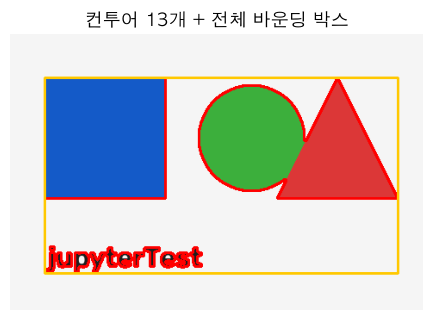

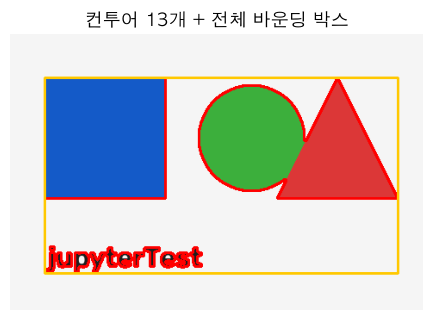

In [9]:
annotated = img.copy()
cv2.drawContours(annotated, contours, -1, (0, 0, 255), 2)
cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 200, 255), 2)

outputs = ROOT / "outputs"
outputs.mkdir(exist_ok=True)
saved = outputs / "opencv_contours.png"
cv2.imwrite(str(saved), annotated)
print(f"저장: outputs/{saved.name} ({saved.stat().st_size:,} bytes)")

imshow(annotated, f"컨투어 {len(contours)}개 + 전체 바운딩 박스")

## 5. 요약 표

| 노트북에서 하지 말 것 | 대신 |
|---|---|
| `cv2.imshow` + `waitKey` | `plt.imshow(cvtColor(img, BGR2RGB))` 또는 `nbtools.imshow` |
| `plt.imshow(bgr)` | 채널 순서 변환 필수 |
| `np.array(contours)` | `np.vstack(contours)` |
| 이중 for 로 min/max | `cv2.boundingRect(np.vstack(contours))` |
| 개인 PC 절대경로 | 저장소 상대경로 + 생성 가능한 샘플 |
| `imread` 결과 미검사 | `None` 검사 후 진행 |

## 6. OpenCV 자체를 더 배우려면

이 노트북은 **주피터 환경에서의 문제**만 다뤘다. 이미지 처리 자체(색공간·필터·이진화·모폴로지·
컨투어·특징점·동영상)는 같은 계정의 **[opencvStudy](https://github.com/SungmanHan/opencvStudy)**
저장소에 레슨 16개로 정리해 두었다. 이 저장소의 옛 OpenCV 실험들이 하려던 것이 거기서 순서대로 이어진다.